In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bạn nhớ dán đường dẫn vừa "Copy path" vào giữa 2 dấu nháy đơn này nhé
file_path = '/content/Banking_Transactional_Dataset.xlsx'

# Sử dụng hàm read_excel để đọc định dạng .xlsx
df = pd.read_excel(file_path)

# Hiển thị 5 dòng đầu tiên để kiểm tra
display(df.head())

# Kiểm tra thông tin các cột, kiểu dữ liệu
print("-" * 50)
df.info()

,TransactionID,CustomerID,TransactionDate,TransactionType,Amount,ProductCategory,ProductSubcategory,BranchCity,BranchLat,BranchLong,Channel,Currency,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome,CustomerSegment,RecommendedOffer
0,1,8270,2025-01-29,Card Payment,6980.185223,Checking Account,Gold,Seville,37.3891,-5.9845,Branch,EUR,0.0,0.00,0.0,839,5767.68,Middle Income Segment,Mid-tier Savings Booster
1,2,1860,2023-02-10,Deposit,10786.371854,Mortgage,Gold,Murcia,37.9847,-1.1287,Branch,EUR,0.0,0.00,0.0,683,2441.00,Low Income Segment,Financial Literacy Program Access
2,3,6390,2024-03-07,Transfer,3982.761111,Loan,Platinum,Malaga,36.7213,-4.4214,ATM,EUR,0.0,92.46,0.0,500,9957.08,High Income Segment,Premium Investment Services
3,4,6191,2023-07-04,Withdrawal,12408.644136,Mortgage,Standard,Seville,37.3891,-5.9845,ATM,EUR,0.0,0.00,0.0,392,1545.80,Low Income Segment,Financial Literacy Program Access
4,5,6734,2025-02-05,Fee,1868.260998,Checking Account,Platinum,Murcia,37.9847,-1.1287,Mobile,USD,0.0,0.00,0.0,368,5825.27,Middle Income Segment,Mid-tier Savings Booster


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   TransactionID       20000 non-null  int64         
 1   CustomerID          20000 non-null  int64         
 2   TransactionDate     20000 non-null  datetime64[ns]
 3   TransactionType     20000 non-null  object        
 4   Amount              20000 non-null  float64       
 5   ProductCategory     20000 non-null  object        
 6   ProductSubcategory  20000 non-null  object        
 7   BranchCity          20000 non-null  object        
 8   BranchLat           20000 non-null  float64       
 9   BranchLong          20000 non-null  float64       
 10  Channel             20000 non-null  object        
 11  Currency            20000 non-null  object        
 12  CreditCardFees      20000 non-null  float64       


In [6]:
# 1. Tạo bản sao của dữ liệu để xử lý
df_ml = df.copy()

# 2. Trích xuất đặc trưng từ cột TransactionDate
df_ml['Year'] = df_ml['TransactionDate'].dt.year
df_ml['Month'] = df_ml['TransactionDate'].dt.month
df_ml['DayOfWeek'] = df_ml['TransactionDate'].dt.dayofweek

# 3. Xóa các cột không cần thiết cho dự báo (ID, Tọa độ, Ngày gốc)
cols_to_drop = ['TransactionID', 'CustomerID', 'TransactionDate', 'BranchLat', 'BranchLong', 'Currency']
df_ml = df_ml.drop(columns=cols_to_drop)

# 4. Xác định biến mục tiêu (y) và biến đầu vào (X)
X = df_ml.drop(columns=['Amount']) # Các biến đầu vào
y = df_ml['Amount'] # Biến mục tiêu cần dự báo

# 5. Mã hóa các biến phân loại (chữ) thành số bằng One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# Kiểm tra lại kích thước dữ liệu sau khi mã hóa
print(f"Kích thước tập X sau mã hóa: {X_encoded.shape}")
display(X_encoded.head())

Kích thước tập X sau mã hóa: (20000, 39)


,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome,Year,Month,DayOfWeek,TransactionType_Deposit,TransactionType_Fee,...,Channel_Mobile,Channel_Online,CustomerSegment_Low Income Segment,CustomerSegment_Middle Income Segment,RecommendedOffer_Financial Literacy Program Access,RecommendedOffer_Gold Card with Travel Benefits,RecommendedOffer_Mid-tier Savings Booster,RecommendedOffer_No-Fee Basic Account,RecommendedOffer_Personal Loan Cashback Offer,RecommendedOffer_Premium Investment Services
0,0.0,0.00,0.0,839,5767.68,2025,1,2,False,False,...,False,False,False,True,False,False,True,False,False,False
1,0.0,0.00,0.0,683,2441.00,2023,2,4,True,False,...,False,False,True,False,True,False,False,False,False,False
2,0.0,92.46,0.0,500,9957.08,2024,3,3,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.0,0.00,0.0,392,1545.80,2023,7,1,False,False,...,False,False,True,False,True,False,False,False,False,False
4,0.0,0.00,0.0,368,5825.27,2025,2,2,False,True,...,True,False,False,True,False,False,True,False,False,False


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Chia tập dữ liệu (Train/Test Split): 80% để huấn luyện, 20% để kiểm thử
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 2. Chuẩn hóa dữ liệu (Data Scaling)
# Giúp các biến có thang đo lớn (như Thu nhập) không lấn át các biến nhỏ (như Điểm tín dụng)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Lưu ý: Chỉ transform trên tập Test

# 3. Khởi tạo 3 mô hình theo yêu cầu đồ án
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

# 4. Vòng lặp Huấn luyện và Đánh giá
results = []
print("Đang huấn luyện các mô hình, vui lòng đợi vài giây...\n")

for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_train_scaled, y_train)

    # Dự đoán trên tập kiểm thử
    y_pred = model.predict(X_test_scaled)

    # Tính toán các độ đo sai số
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Lưu kết quả
    results.append({
        "Mô hình": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R² Score": round(r2, 4)
    })

# Hiển thị bảng so sánh kết quả
results_df = pd.DataFrame(results)
display(results_df)

Đang huấn luyện các mô hình, vui lòng đợi vài giây...



,Mô hình,MAE,RMSE,R² Score
0,Linear Regression,2535.24,3075.49,0.2472
1,Random Forest,2592.28,3177.67,0.1964
2,XGBoost,2629.17,3253.64,0.1575


/tmp/ipykernel_781/4013569573.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mức độ quan trọng', y='Đặc trưng', data=top_10_features, palette='viridis')


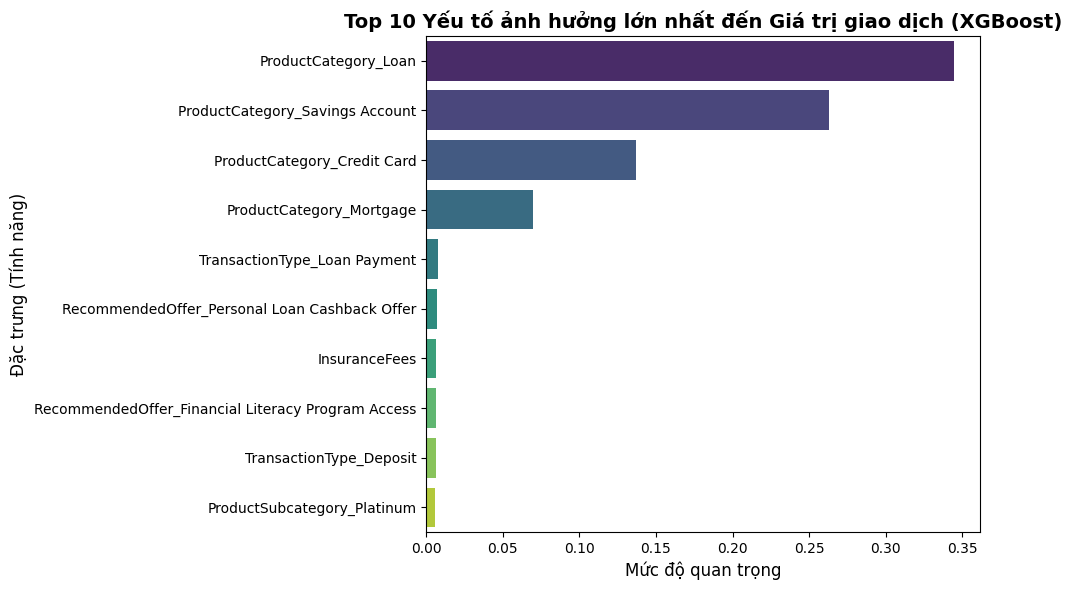

In [8]:
# Lấy mô hình XGBoost từ danh sách đã huấn luyện
best_model = models["XGBoost"]

# Trích xuất mức độ quan trọng của các biến đầu vào
feature_importances = best_model.feature_importances_

# Tạo DataFrame để dễ sắp xếp và trực quan hóa
importance_df = pd.DataFrame({
    'Đặc trưng': X_encoded.columns,
    'Mức độ quan trọng': feature_importances
})

# Sắp xếp giảm dần và lấy Top 10 đặc trưng quan trọng nhất
top_10_features = importance_df.sort_values(by='Mức độ quan trọng', ascending=False).head(10)

# Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 6))
sns.barplot(x='Mức độ quan trọng', y='Đặc trưng', data=top_10_features, palette='viridis')

plt.title('Top 10 Yếu tố ảnh hưởng lớn nhất đến Giá trị giao dịch (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Đặc trưng (Tính năng)', fontsize=12)
plt.tight_layout()
plt.show()